In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Data Preparation

In [4]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [7]:
!wget $data -O data-week-3.csv

--2026-09-09 10:51:08--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [text/plain]
Saving to: ‘data-week-3.csv’

data-week-3.csv     100%[===================>] 954,59K  --.-KB/s    in 0,1s    

2026-09-09 10:51:09 (6,50 MB/s) - ‘data-week-3.csv’ saved [977501/977501]



In [8]:
df = pd.read_csv('data-week-3.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.columns = df.columns.str.lower().str.replace(' ','_')
categorical_cols = list(df.dtypes[df.dtypes == 'object'].index)+list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_cols:
    df[c] = df[c].str.lower().str.replace(' ','_')

In [14]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

In [15]:
pd.to_numeric(df.totalcharges)

ValueError: Unable to parse string "_" at position 488

In [16]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')

In [17]:
tc.isnull().sum()

np.int64(11)

In [18]:
df[tc.isnull()][['customerid','totalcharges']]

,customerid,totalcharges
488,4472-lvygi,_
753,3115-czmzd,_
936,5709-lvoeq,_
1082,4367-nuyao,_
1340,1371-dwpaz,_
3331,7644-omvmy,_
3826,3213-vvolg,_
4380,2520-sgtta,_
5218,2923-arzlg,_
6670,4075-wkniu,_


In [19]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

## Encoding Target variable

In [20]:
df.churn.head()

0     no
1     no
2    yes
3     no
4    yes
Name: churn, dtype: str

In [21]:
df.churn = (df.churn == 'yes').astype(int)

In [22]:
df.churn.head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

# Setting up the validation Framework

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [27]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [28]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [29]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [30]:
y_train = df_train.churn
y_val = df_val.churn
y_test = df_test.churn

In [31]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

# EDA

In [32]:
df_full_train = df_full_train.reset_index(drop=True)

## Missing Vals

In [33]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

## Looking at the target: churn rate

In [34]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [35]:
df_full_train.churn.mean()

np.float64(0.26996805111821087)

## Numerical and categorical variables

In [36]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [44]:
categorical = [c for c in df.columns if c not in numerical and c != 'customerid' and c != 'churn']
categorical

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [45]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

# Feature importance: Churn rate and risk ratio

## Churn rate per group

In [46]:
global_churn = df_full_train.churn.mean()

In [47]:
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()

In [48]:
global_churn, churn_female, churn_male

(np.float64(0.26996805111821087),
 np.float64(0.27682403433476394),
 np.float64(0.2632135306553911))

In [49]:
global_churn - churn_female

np.float64(-0.006855983216553063)

In [50]:
global_churn - churn_male

np.float64(0.006754520462819769)

Both differences are close to zero, so gender is probably not an important feature

In [51]:
df_full_train.partner.value_counts()

partner
no     2932
yes    2702
Name: count, dtype: int64

In [52]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()

In [53]:
churn_partner, churn_no_partner

(np.float64(0.20503330866025166), np.float64(0.3298090040927694))

In [54]:
global_churn - churn_partner

np.float64(0.06493474245795922)

In [55]:
global_churn - churn_no_partner

np.float64(-0.05984095297455855)

pos diff means the group churns less than average, and negative diff means it churns more. The larger the abs difference, the more important the var

## Risk Ratio

$DIFFERENCE = GLOBAL - GROUP$
<ol>
<li> <0 -> more likely
<li> >0 -> less likely
<lo>

$Risk = \frac{GROUP}{GLOBAL}$

<ol>
<li> >1 -> more likely
<li> <1 -> less likely
<ol>

In [56]:
churn_no_partner / global_churn

np.float64(1.2216593879412643)

In [57]:
churn_partner / global_churn

np.float64(0.7594724924338315)

risk ratio reads:

<ol>
<li> risk = 1 means the group is as likely as everyone else
<li> risk > 1 means the group is more likely
<li> risk < 1 means the group is less likely
<ol>

We can do this for every variable, which translate in SQL query:

``` sql
SELECT
    gender,
    AVG(churn),
    AVG(churn) - global_churn AS diff,
    AVG(churn) / global_churn AS risk
FROM
    data
GROUP BY
    gender;
```


In [58]:
from IPython.display import display

for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


internet service, contract type and payment method look important.

# Feature importance: Mutual Info

churn rate and risk ratio tells us which groups within one variable churn more, but don't let us compare whole variables with each other. Mutual information fixes this: it is a single number per variable that measures how important it is.

## concept

Mutual info is a concept of information theory. Tells us how much we can learn about one variable if we know the value of another.

### Information Theory

$H(X|Y) -> X=H(X)$ entropy $H(Y|X) -> Y=H(Y)$ entropy $I(X;Y)$ mutual info $H(X,Y)$ Joint entropy

In [59]:
from sklearn.metrics import mutual_info_score

In [60]:
mutual_info_score(df_full_train.churn, df_full_train.contract)

0.0983203874041556

In [61]:
mutual_info_score(df_full_train.churn, df_full_train.gender)

0.0001174846211139946

In [62]:
mutual_info_score(df_full_train.churn, df_full_train.partner)

0.009967689095399745

In [63]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [64]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

# Feature Importance: Correlation

Mutual info measures the importance of categorical variables. For numerical variables we use correlation coefficient instead: tells us how strongly each numerical feature is related to target.

## Correlation coefficient

usually denoted r, measures the degree of dependency between two variables. It is always a number between -1 and 1:
<lo>
<li> A value close to 1 means strong positive correlation: when one variable grow, the other grows too.
<li> A value close to -1 means strong negative correlation: when one variable grows, the other decreases.
<li> A value close to 0 means there is no dependency: a change in one variable tells us nothing about the other.
<lo>

The sign gives the direction of the relationship, and the absolute value gives its strength. One way to interpret the magnitude:
<lo>
<li> LOW when the absolute value of r is between 0 and 0.2
<li> MEDIUM when the absolute value of r is between 0.2 and 0.5
<li> HIGH when the absolute value of r is between 0.5 and 1.0
<lo>

This works for both pos and neg correlation

In [65]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [66]:
df_full_train[numerical].corrwith(df_full_train.churn).abs()

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

In [67]:
df_full_train.tenure.max()

np.int64(72)

In [73]:
less_than_two = df_full_train[df_full_train.tenure <= 2].churn.mean()

In [74]:
two_to_one_year = df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

In [75]:
more_than_one_year = df_full_train[df_full_train.tenure > 12].churn.mean()

In [76]:
groups = ["0-2 months", "2-12 months", "12+ months"]
values = [round(less_than_two,2)*100, round(two_to_one_year,2)*100, round(more_than_one_year,2)*100]

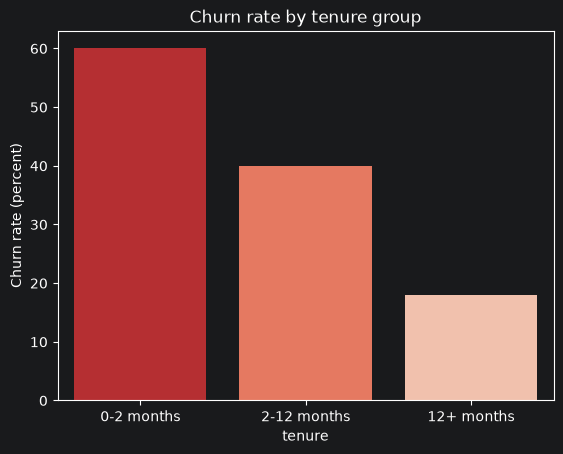

In [79]:
sns.barplot(x=groups, y=values, palette="Reds_r", hue=groups)
plt.title("Churn rate by tenure group")
plt.xlabel("tenure")
plt.ylabel("Churn rate (percent)")
plt.show()

In [81]:
less = df_full_train[df_full_train.monthlycharges <= 20].churn.mean()
medium = df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges<=50)].churn.mean()
high = df_full_train[df_full_train.monthlycharges > 50].churn.mean()

In [82]:
groups = ["<=20", "20-50", ">50"]
values = [round(less,2)*100, round(medium,2)*100, round(high,2)*100]

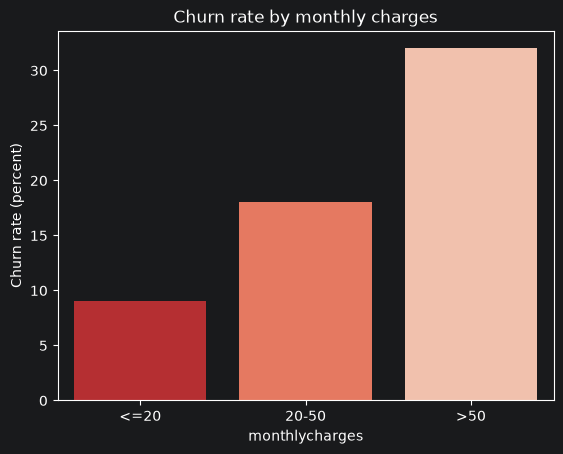

In [83]:
sns.barplot(x=groups, y=values, palette="Reds_r", hue=groups)
plt.title("Churn rate by monthly charges")
plt.xlabel("monthlycharges")
plt.ylabel("Churn rate (percent)")
plt.show()

# One-hot encoding

## Why we need encoding?

Machine learning models work with numbers. Our numerical variables are already numbers. But categorical contain strings. We cannot multiply a string by a weight, so we need to translate these into numbers first

## One-hot encoding

Replaces one categorical column with several binary columns, one per category. Each new column says whether the row has that category(1) or not (0).

In [84]:
dicts = df[categorical+numerical].to_dict(orient='records')

In [85]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical+numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

In [87]:
X_train.shape

(4225, 45)

In [88]:
val_dict = df_val[categorical+numerical].to_dict(orient='records')
X_val = dv.fit_transform(val_dict)
X_val.shape

(1409, 45)

# Logistic Regression

## Binary Classification

Target variable takes one of two values. Encoded as 1 for the positive class and 0 for the negative class. A supervised model is a function that maps features to the target: $g(x_i) = y_i$. For classification, the output of g is a number between 0 and 1: the probability that $x_i$ belogns to the positive class. If the model outputs 0.8 we say there is an 80% chance it belongs to the positive class


## From Linear to Logistic regression

Linear regression computes a weighted sum of the features: $g(x_i) = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n$ here w0 is the bias term (what we predict when all features are zero) and $w1....wn$ are the weights, each one says how much its features contributes to the prediction. The output can be any real number, which is fine for predicting a price, but a probability must stay between 0 and 1.

Logistic regresstion is the same linear model with one extra step: we apply the sigmoid function to the weighted sum: $g(x_i) = sigmoid(w_0+w_1x_1+w_2x_2+...+w_nx_n)$

Sigmoid(z) = \frac{1}{1+exp(-z)}

The sigmoid squashes any real number into the range between 0 and 1. That turns the raw score into a probability. Both models are called linear, because the score inside is still a linear combination of the features, only the final transformation differs.

In [89]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [91]:
sigmoid(10000)

np.float64(1.0)

Large pos score maps to 1.0. A large negative score maps to 0, and at exactly 0 the sigmoid gives 0.5, a coin flip.

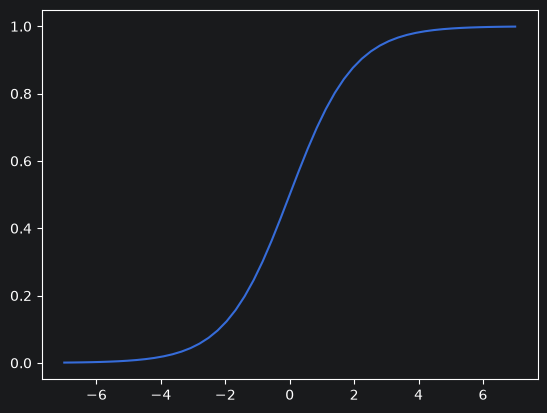

In [92]:
z=np.linspace(-7,7,51)
plt.plot(z,sigmoid(z))

The curve has an S shape: scores below roughly -5 give a probability close to 0, score above roughly 5 give a probability close to 1, and everything in between moves smoothly between the two extremes. A score 0 means a 50% chance.

In [93]:
def linear_regression(xi):
    res = w0

    for j in range(len(xi)):
        res += xi[j]*w[j]
    return res

In [94]:
def logistic_regression(xi):
    res = w0

    for j in range(len(xi)):
        res += xi[j]* w[j]
    res = sigmoid(res)
    return res

# Training Logistic Regression with scikit-learn

In [95]:
from sklearn.linear_model import LogisticRegression

In [98]:
model = LogisticRegression(solver='lbfgs', max_iter=10000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

'solver' is the optimization algo that finds the best weights.

In [99]:
model.intercept_[0]

np.float64(-0.04544302938501822)

In [100]:
model.coef_[0].round(3)

array([ 0.686,  0.032, -0.678,  0.055, -0.015,  0.113, -0.16 ,  0.087,
        0.039,  0.001, -0.498,  0.698, -0.16 , -0.018, -0.188,  0.068,
        0.159,  0.117, -0.16 ,  0.083,  0.284, -0.16 , -0.085, -0.161,
        0.201, -0.044,  0.084, -0.053, -0.002,  0.107, -0.011,  0.068,
       -0.028,  0.195, -0.095, -0.16 ,  0.295, -0.055, -0.16 ,  0.255,
        0.234, -0.16 , -0.034, -0.068,  0.   ])

<lo>
<li> model.predict(X) gives hard predictions, final 0/1 answer
<li> model.predict_proba(X) gives soft predictions, the actual proba
<lo>

In [101]:
y_pred = model.predict_proba(X_val)[:,1]

In [102]:
churn_decision = (y_pred >= 0.5)

In [103]:
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

In [104]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [105]:
df_pred['correct'] = df_pred.prediction == df_pred.actual
df_pred.correct.mean()

np.float64(0.8034066713981547)

# Model Interpretation

model.coef_[0] is just an array of numbers, we don't know which weight belongs to which column.

In [106]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.686),
 'contract=one_year': np.float64(0.032),
 'contract=two_year': np.float64(-0.678),
 'dependents=no': np.float64(0.055),
 'dependents=yes': np.float64(-0.015),
 'deviceprotection=no': np.float64(0.113),
 'deviceprotection=no_internet_service': np.float64(-0.16),
 'deviceprotection=yes': np.float64(0.087),
 'gender=female': np.float64(0.039),
 'gender=male': np.float64(0.001),
 'internetservice=dsl': np.float64(-0.498),
 'internetservice=fiber_optic': np.float64(0.698),
 'internetservice=no': np.float64(-0.16),
 'monthlycharges': np.float64(-0.018),
 'multiplelines=no': np.float64(-0.188),
 'multiplelines=no_phone_service': np.float64(0.068),
 'multiplelines=yes': np.float64(0.159),
 'onlinebackup=no': np.float64(0.117),
 'onlinebackup=no_internet_service': np.float64(-0.16),
 'onlinebackup=yes': np.float64(0.083),
 'onlinesecurity=no': np.float64(0.284),
 'onlinesecurity=no_internet_service': np.float64(-0.16),
 'onlinesecurity=yes': np.flo

In [107]:
small = ['contract', 'tenure','monthlycharges']

dicts_train_small = df_train[small].to_dict(orient='records')
dict_val_small = df_val[small].to_dict(orient='records')

In [108]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

DictVectorizer(sparse=False)

In [110]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [111]:
X_train_small = dv_small.transform(dicts_train_small)
model_small = LogisticRegression(solver='lbfgs', max_iter=10000)
model_small.fit(X_train_small, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [112]:
w0 = model_small.intercept_[0]
w0

np.float64(-2.477957595284362)

In [113]:
w = model_small.coef_[0]
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

{'contract=month-to-month': np.float64(0.971),
 'contract=one_year': np.float64(-0.024),
 'contract=two_year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

# Using the model

In [114]:
dicts_full_train = df_full_train[categorical+numerical].to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

y_full_train = df_full_train.churn.values

In [115]:
model = LogisticRegression(solver='lbfgs', max_iter=10000)
model.fit(X_full_train, y_full_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [116]:
dicts_test = df_test[categorical+numerical].to_dict(orient='records')
X_test = dv.transform(dicts_test)

y_pred = model.predict_proba(X_test)[:,1]
churn_decision = (y_pred >= 0.5)
(churn_decision == y_test).mean()

np.float64(0.8097941802696949)

In [117]:
customer = dicts_test[-1]
customer

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'no',
 'deviceprotection': 'yes',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month-to-month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 17,
 'monthlycharges': 104.2,
 'totalcharges': 1743.5}

In [118]:
x_small = dv.transform([customer])
model.predict_proba(x_small)[0,1]

np.float64(0.638051474977529)

In [123]:
y_test

0       0
1       0
2       0
3       1
4       0
       ..
1404    1
1405    0
1406    0
1407    0
1408    1
Name: churn, Length: 1409, dtype: int64